In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
%pip install scikit-learn matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set(style="whitegrid")
print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [2]:
df = pd.read_csv('Cleaned_Customer_Transactions_BI.csv', parse_dates=['Transaction_Date'])
df['Price_Segment'] = df['Price_Segment'].fillna('Standard')
df.head()

,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_trans,Total_Cost,Product_Name,Product_Price_prod,Company_Name,Company_Profit,Address,City,Product_Price,Month,Year,DayOfWeek,Is_Weekend,Is_High_Profit_Client,Price_Segment
0,1.00,88.00,6.00,6.00,2024-03-26,194379.15,1075200.00,RevenueVue Dashboard,179200,Elite Consulting 88,75950.00,"EDSA, Barangay 456, Taguig, Philippines",Taguig,179200,3,2024,Tuesday,0,0,Premium
1,2.00,29.00,19.00,16.00,2024-07-09,97930.99,1428000.00,EcoNomix Modeler,95200,Sky Industries 29,61952.00,"Edsa, brgy. 606, makati, philippines!",Makati,95200,7,2024,Tuesday,0,0,Standard
2,3.00,28.00,18.00,6.00,2024-04-13,126095.55,940800.00,DashSync Analytics Hub,134400,Global Holdings 28,61115.00,"Katipunan Ave, Brgy. 303, Taguig, Philippines",Taguig,134400,4,2024,Saturday,1,0,Standard
3,4.00,85.00,12.00,12.00,2023-09-06,NaN,1008000.00,BudgetMaster Pro,84000,Green Ventures 85,113470.00,"EDSA, Barangay 707, Cebu City, Philippines",Cebu City,84000,9,2023,Wednesday,0,1,Standard
4,5.00,47.00,3.00,8.00,2021-07-06,99575.61,705600.00,TrendWise Forecaster,100800,Green Industries 47,31130.00,"Taft Ave, Barangay 707, Mandaluyong, Philippines",Mandaluyong,100800,7,2021,Tuesday,0,0,Standard


In [3]:
df['YearMonth'] = df['Transaction_Date'].dt.to_period('M')
df_monthly = df.groupby('YearMonth')['Total_Cost'].sum().reset_index()
df_monthly['YearMonth'] = df_monthly['YearMonth'].dt.to_timestamp()
df_monthly['Month_Index'] = range(len(df_monthly))
df_monthly.head()

,YearMonth,Total_Cost,Month_Index
0,2020-01-01,2783200.00,0
1,2020-02-01,11104800.00,1
2,2020-03-01,1366400.00,2
3,2020-04-01,5656000.00,3
4,2020-05-01,3903200.00,4


In [4]:
df_monthly['Lag_1'] = df_monthly['Total_Cost'].shift(1).fillna(method='bfill')
df_monthly['Lag_2'] = df_monthly['Total_Cost'].shift(2).fillna(method='bfill')
df_monthly['Rolling_3'] = df_monthly['Total_Cost'].rolling(window=3, min_periods=1).mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_21476\778569084.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_monthly['Lag_1'] = df_monthly['Total_Cost'].shift(1).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_21476\778569084.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_monthly['Lag_2'] = df_monthly['Total_Cost'].shift(2).fillna(method='bfill')


In [5]:
X = df_monthly[['Month_Index','Lag_1','Lag_2','Rolling_3']]
y = df_monthly['Total_Cost']

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X, y)

# Evaluate
y_pred = rf_model.predict(X)
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}, R2: {r2_score(y, y_pred):.4f}")

RMSE: 15489538.71, R2: 0.9728


In [6]:
future_index = np.arange(len(df_monthly), len(df_monthly)+6)
last_sales = df_monthly['Total_Cost'].tolist()
forecast_data = []

for i in range(6):
    lag_1 = last_sales[-1]
    lag_2 = last_sales[-2]
    rolling_3 = np.mean(last_sales[-3:])
    pred = rf_model.predict([[future_index[i], lag_1, lag_2, rolling_3]])[0]
    forecast_data.append([future_index[i], pred])
    last_sales.append(pred)

forecast_overall = pd.DataFrame(forecast_data, columns=['Month_Index','Forecasted_Sales'])
forecast_overall['YearMonth'] = pd.date_range(start=df_monthly['YearMonth'].iloc[-1]+pd.offsets.MonthBegin(), periods=6, freq='MS')
forecast_overall.head()

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\ana

,Month_Index,Forecasted_Sales,YearMonth
0,60,26879048.00,2025-01-01
1,61,31675084.00,2025-02-01
2,62,49417704.00,2025-03-01
3,63,49554540.00,2025-04-01
4,64,49002884.00,2025-05-01


In [7]:
# Aggregate monthly sales by City × Price_Segment
df_city_product = df.groupby(['YearMonth','City','Price_Segment'])['Total_Cost'].sum().reset_index()
if pd.api.types.is_period_dtype(df_city_product['YearMonth']):
    df_city_product['YearMonth'] = df_city_product['YearMonth'].dt.to_timestamp()

df_city_product = df_city_product.sort_values(['City','Price_Segment','YearMonth'])

# Create rolling and lag features
df_city_product['Rolling_3'] = df_city_product.groupby(['City','Price_Segment'])['Total_Cost']\
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
df_city_product['Lag_1'] = df_city_product.groupby(['City','Price_Segment'])['Total_Cost'].shift(1).fillna(method='bfill')
df_city_product['Lag_2'] = df_city_product.groupby(['City','Price_Segment'])['Total_Cost'].shift(2).fillna(method='bfill')

# Forecast per City × Price_Segment
forecast_results = []
city_product_combos = df_city_product[['City','Price_Segment']].drop_duplicates()

for _, row in city_product_combos.iterrows():
    city, segment = row['City'], row['Price_Segment']
    subset = df_city_product[(df_city_product['City']==city) & (df_city_product['Price_Segment']==segment)].reset_index(drop=True)
    subset['Month_Index'] = range(len(subset))
    
    X_sub = subset[['Month_Index','Lag_1','Lag_2','Rolling_3']]
    y_sub = subset['Total_Cost']
    
    model = RandomForestRegressor(n_estimators=150, random_state=42)
    model.fit(X_sub, y_sub)
    
    # Forecast next 6 months
    last_sales = subset['Total_Cost'].tolist()
    future_index = np.arange(len(subset), len(subset)+6)
    future_data = []
    
    for i in range(6):
        lag_1 = last_sales[-1]
        lag_2 = last_sales[-2]
        rolling_3 = np.mean(last_sales[-3:])
        pred = model.predict([[future_index[i], lag_1, lag_2, rolling_3]])[0]
        future_data.append([future_index[i], pred])
        last_sales.append(pred)
    
    future_df = pd.DataFrame(future_data, columns=['Month_Index','Forecasted_Sales'])
    future_df['YearMonth'] = pd.date_range(start=subset['YearMonth'].iloc[-1]+pd.offsets.MonthBegin(), periods=6, freq='MS')
    future_df['City'] = city
    future_df['Price_Segment'] = segment
    
    forecast_results.append(future_df[['YearMonth','City','Price_Segment','Forecasted_Sales']])

forecast_city_product = pd.concat(forecast_results).reset_index(drop=True)
forecast_city_product.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_21476\3898085962.py:3: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df_city_product['YearMonth']):
C:\Users\HP\AppData\Local\Temp\ipykernel_21476\3898085962.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_city_product['Lag_1'] = df_city_product.groupby(['City','Price_Segment'])['Total_Cost'].shift(1).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_21476\3898085962.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_city_product['Lag_2'] = df_city_product.groupby(['City','Price_Segment'])['Total_Cost'].shift(2).fillna(method='bfill')
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

,YearMonth,City,Price_Segment,Forecasted_Sales
0,2025-01-01,Baguio,Premium,8693664.00
1,2025-02-01,Baguio,Premium,9252320.00
2,2025-03-01,Baguio,Premium,6937728.00
3,2025-04-01,Baguio,Premium,7597968.00
4,2025-05-01,Baguio,Premium,7911306.67


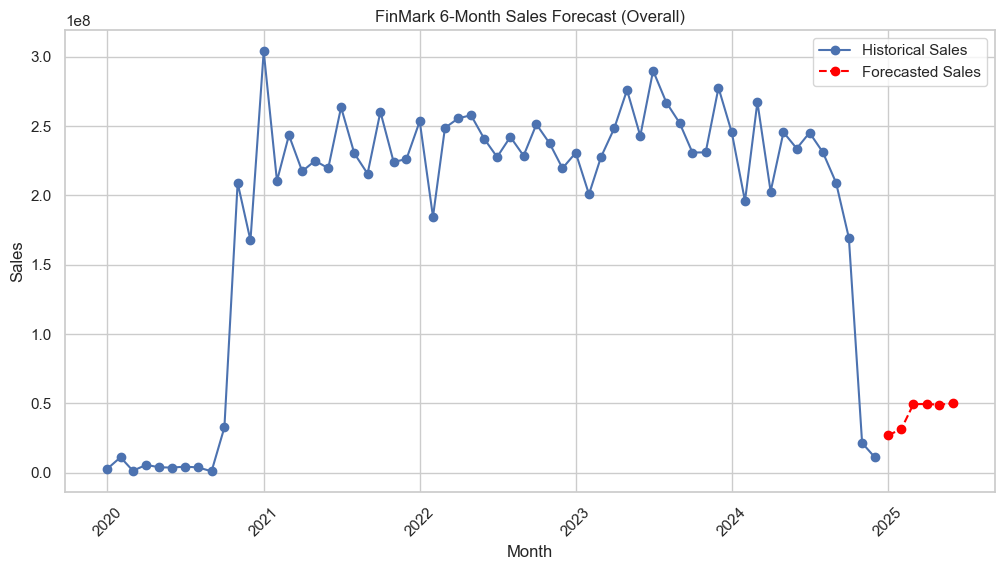

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df_monthly['YearMonth'], df_monthly['Total_Cost'], marker='o', label='Historical Sales')
plt.plot(forecast_overall['YearMonth'], forecast_overall['Forecasted_Sales'], marker='o', linestyle='--', color='red', label='Forecasted Sales')
plt.title('FinMark 6-Month Sales Forecast (Overall)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.show()

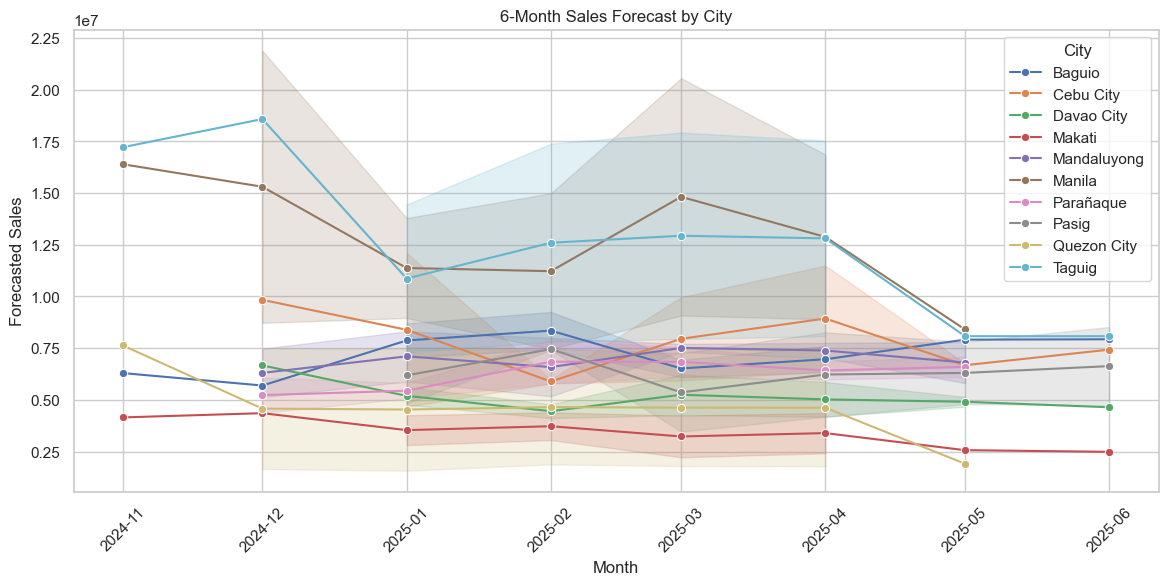

In [9]:
plt.figure(figsize=(14,6))
sns.lineplot(data=forecast_city_product, x='YearMonth', y='Forecasted_Sales', hue='City', marker='o')
plt.title('6-Month Sales Forecast by City')
plt.xlabel('Month')
plt.ylabel('Forecasted Sales')
plt.xticks(rotation=45)
plt.legend(title='City')
plt.show()

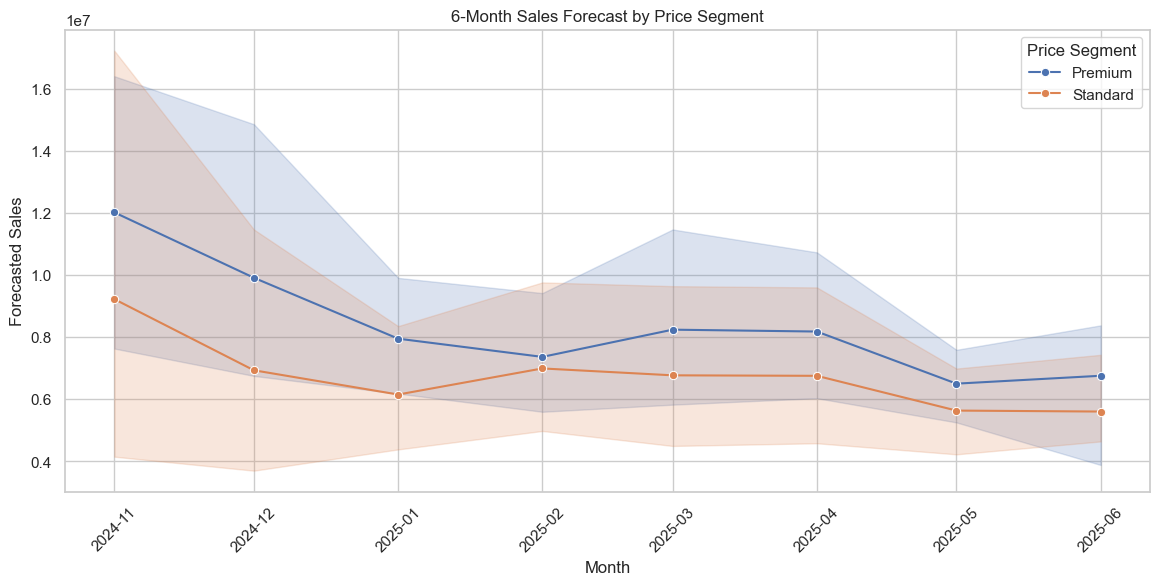

In [10]:
plt.figure(figsize=(14,6))
sns.lineplot(data=forecast_city_product, x='YearMonth', y='Forecasted_Sales', hue='Price_Segment', marker='o')
plt.title('6-Month Sales Forecast by Price Segment')
plt.xlabel('Month')
plt.ylabel('Forecasted Sales')
plt.xticks(rotation=45)
plt.legend(title='Price Segment')
plt.show()

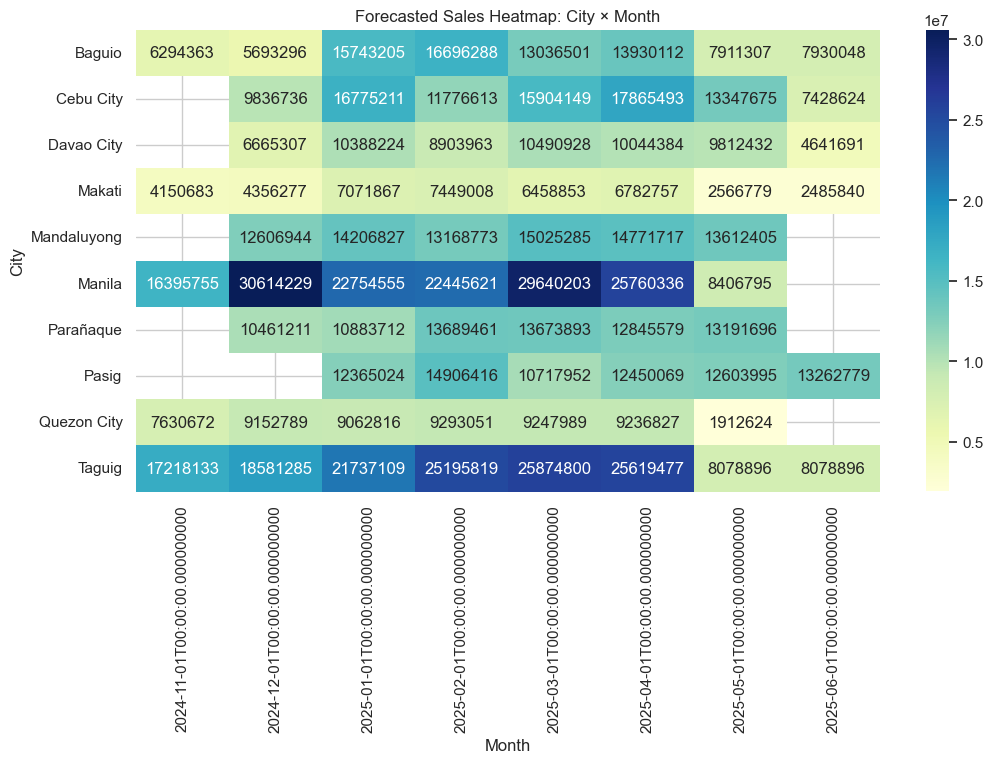

In [11]:
pivot_table = forecast_city_product.pivot_table(index='City', columns='YearMonth', values='Forecasted_Sales', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Forecasted Sales Heatmap: City × Month')
plt.xlabel('Month')
plt.ylabel('City')
plt.show()

In [12]:
# ==========================================
# Save 6-Month Forecast
# ==========================================
forecast_submission = forecast_city_product.copy()

# Reorder columns for clarity
forecast_submission = forecast_submission[['YearMonth', 'City', 'Price_Segment', 'Forecasted_Sales']]

# Format YearMonth nicely
forecast_submission['YearMonth'] = forecast_submission['YearMonth'].dt.strftime('%Y-%m')

# Optional: round forecasted sales
forecast_submission['Forecasted_Sales'] = forecast_submission['Forecasted_Sales'].round(2)

# Save to CSV
forecast_submission.to_csv('Milestone2_6Month_Forecast.csv', index=False)
print("Milestone 2 forecast CSV generated successfully.")
forecast_submission.head(12)  # Display first 12 rows

Milestone 2 forecast CSV generated successfully.


,YearMonth,City,Price_Segment,Forecasted_Sales
0,2025-01,Baguio,Premium,8693664.00
1,2025-02,Baguio,Premium,9252320.00
2,2025-03,Baguio,Premium,6937728.00
3,2025-04,Baguio,Premium,7597968.00
4,2025-05,Baguio,Premium,7911306.67
5,2025-06,Baguio,Premium,7930048.00
6,2024-11,Baguio,Standard,6294362.67
7,2024-12,Baguio,Standard,5693296.00
8,2025-01,Baguio,Standard,7049541.33
9,2025-02,Baguio,Standard,7443968.00
